Seasonal Agricultural Performance Analysis

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float', lambda x: f"{x:,.2f}")

In [ ]:
# Load the dataset

file_path="/content/drive/MyDrive/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded susscessfully")

Dataset loaded susscessfully


Initial Data Understanding

In [ ]:
# Dataset Shape
print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

No. of rows:  4000
No. of columns:  28


In [ ]:
# Top five rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# Bottom five rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
# Column name

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
# Data types and non null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [ ]:
# Catrgorical Summary

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

In [ ]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = ( df.isnull().mean() * 100 ).sort_values(ascending=False)

missing_summary = pd.DataFrame({
     "Missing Count": missing,
     "Missing Percentage": missing_percentage.round(2)
 })
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


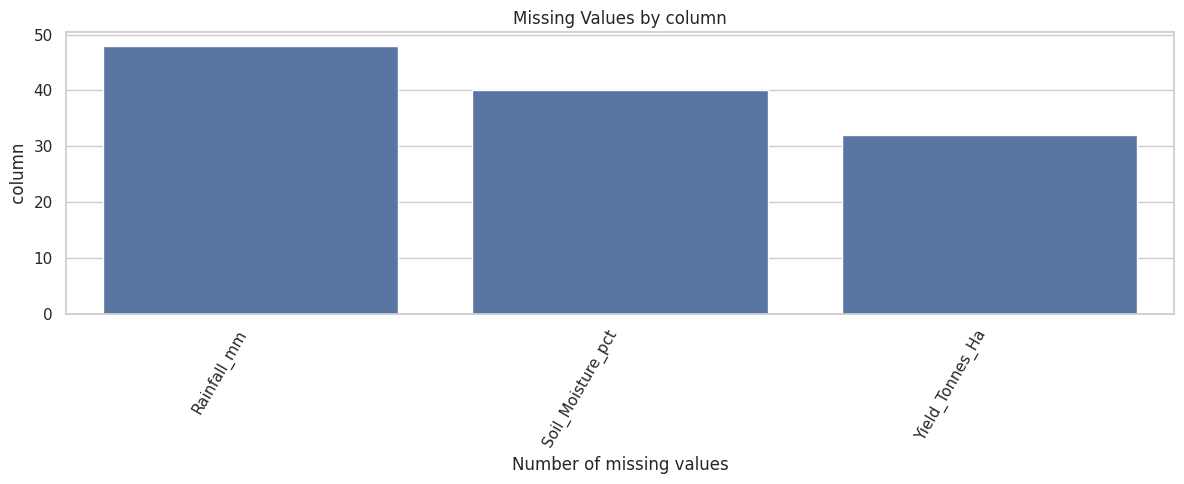

In [ ]:
# Visualize missing values

plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.xlabel("Number of missing values")
    plt.ylabel(" column ")
    plt.title("Missing Values by column")
    plt.tight_layout()
    plt.show()
else:
  print("No missing value found")

In [ ]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("No. of duplicate records: ", duplicate_count)

No. of duplicate records:  0


In [ ]:
# Remove Duplicate rows

df=df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [ ]:
# Check data types again
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
# Check Unique values for categorical columns

categorical_column = df.select_dtypes(include="object").columns

for col in categorical_column:
  print(f"\n{col}")
  print(df[col].nunique(),"unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
# Check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head()

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0


Missing values Treatement

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:

1. Remove records only when justified.
2. Fill numerical values using an appropriate statistic
3. Fill categorical values using a sutaible categorical method
4. Clearly document why the choosen approach is reasonable.

In [ ]:
# median impuation for numerical columns
numerical_column = df.select_dtypes(include="number").columns

for col in numerical_column:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].median())
print("Remaining missing values: ", df.isnull().sum().sum())

Remaining missing values:  120


In [ ]:
# Numerical and Categorical columns

numerical_column = df.select_dtypes(include=np.number).columns.tolist()
categorical_column = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns: ", numerical_column)
print("Categorical columns: ", categorical_column)

Numerical columns:  ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns:  ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


Statistical Analysis

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [ ]:
# Descriptive statistics

stats=df[numerical_column].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20","1,315.20",464.75
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00,39.00,9.60
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [ ]:
# Median and Standard deviation

statical_summary = pd.DataFrame({
    "Mean": df[numerical_column].mean(),
    "Median": df[numerical_column].median(),
    "Standard Deviation": df[numerical_column].std(),
    "Variance": df[numerical_column].var(),
    "Min": df[numerical_column].min(),
    "Max": df[numerical_column].max()

})
statical_summary

,Mean,Median,Standard Deviation,Variance,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,17.84,0.50,15.00
Rainfall_mm,601.15,582.00,288.93,"83,477.67",80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,14.58,16.20,39.70
Humidity_pct,63.21,63.00,11.96,143.06,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,1.26,3.50,11.00
Soil_pH,6.70,6.69,0.64,0.41,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.71,45.06,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,974.47,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,289.51,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,769.66,30.00,200.00


In [ ]:
# Seasonal descriptive summary

seasonal_summary = df.groupby("Season")[numerical_column].agg(["mean", "median", "std" ])
seasonal_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      852.08 854.75 182.55   
Rabi                 7.75   7.68 4.18      436.00 430.30 175.66   
Zaid                 8.09   8.09 4.16      299.42 283.30 153.98   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.20   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.05   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.17   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.20 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.96         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.90         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.64   1.95 14.42             46.31  13.24 135.70   
Rabi              5.08   1.66 12.83             41.49  11.08 121.90   
Zaid              4.67   1.45 11.32             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

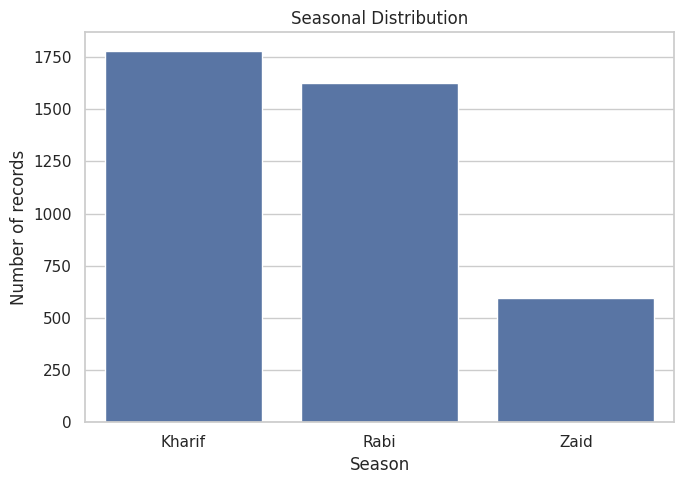

In [ ]:
# Unvariate season distribution
plt.figure(figsize = (7,5))
sns.countplot(data=df, x="Season")
plt.title("Seasonal Distribution")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

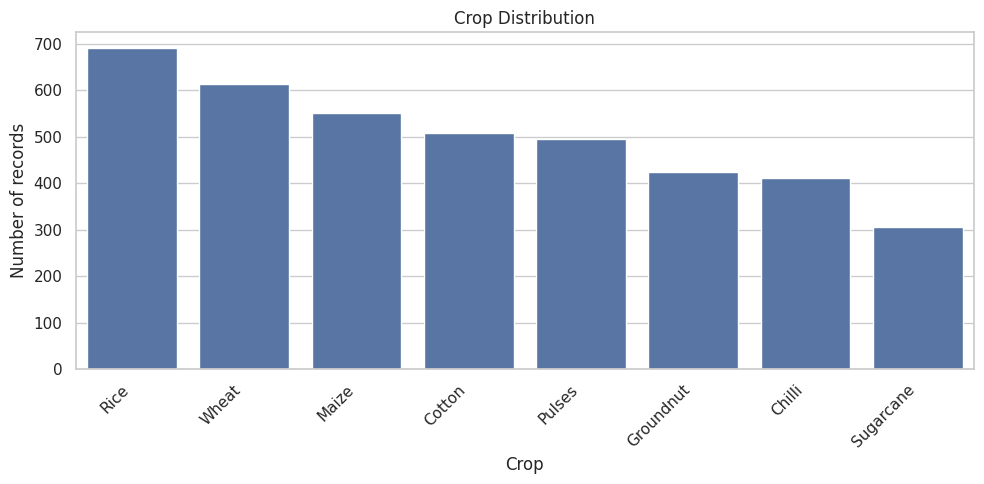

In [ ]:
# Unvariate: Crop Distribution
plt.figure(figsize = (10,5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

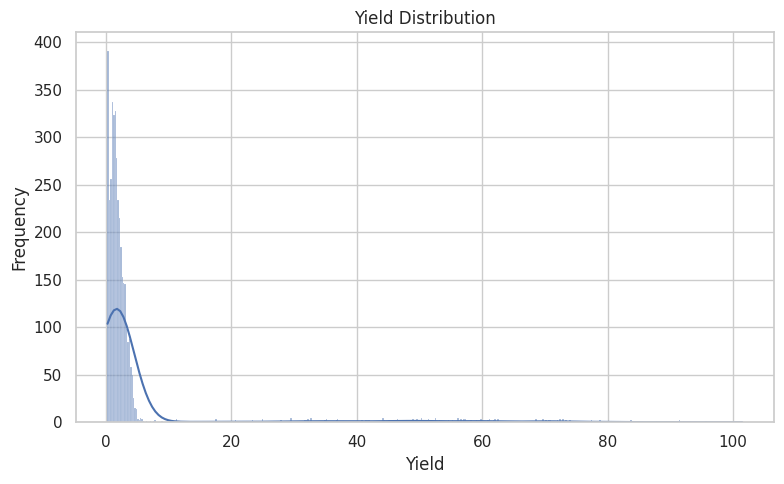

In [ ]:
# Unvariate Yield distriburtion
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

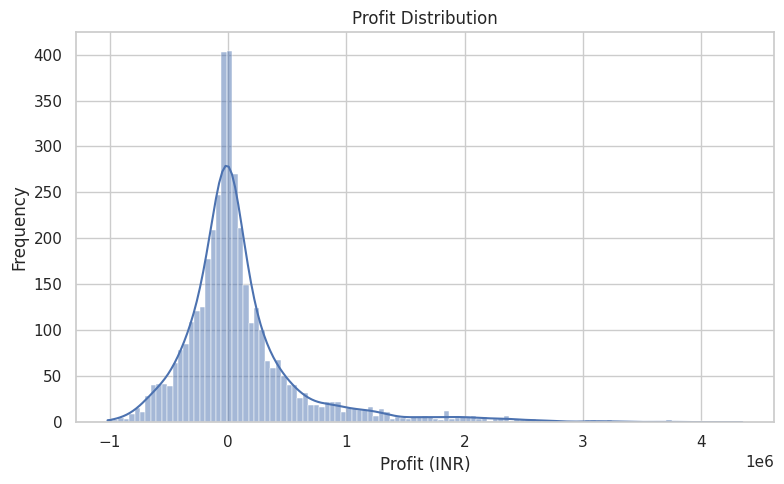

In [ ]:
# Unvariate: profit distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

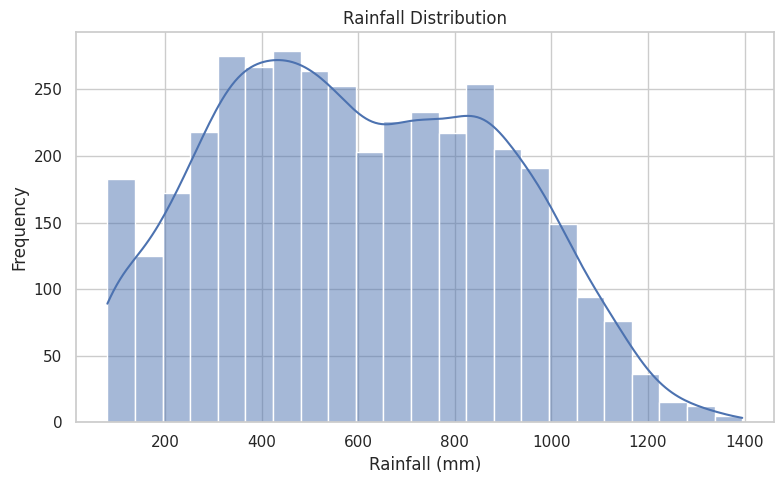

In [ ]:
# Unvariate: Rainfall distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

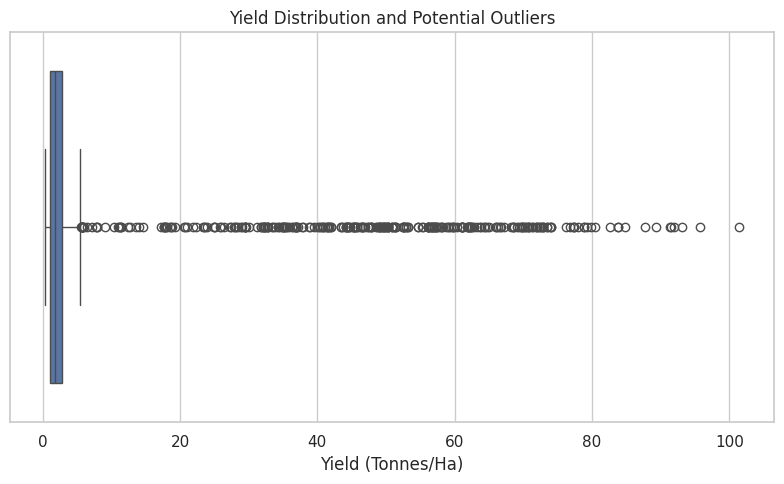

In [ ]:
# Unvariate: Boxplot for Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.xlabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

Outlier Analysis

Univariate: Season distribution (Pie Chart)

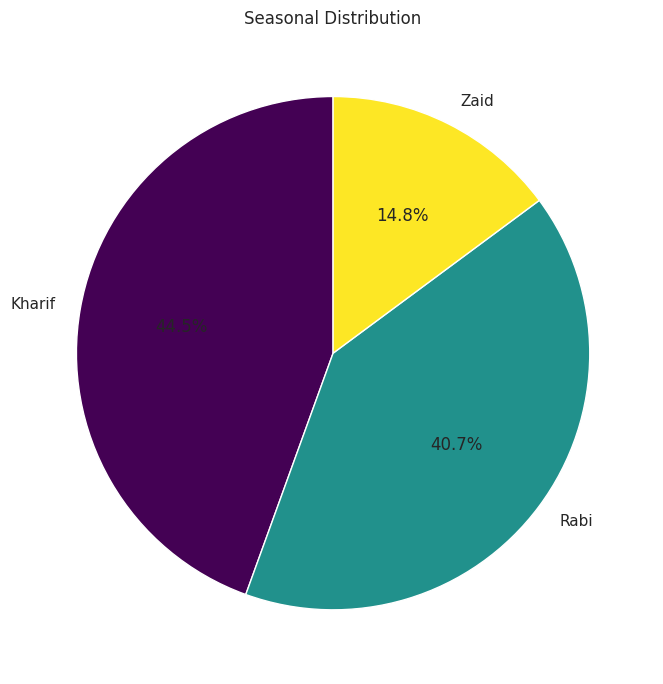

In [ ]:
plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, cmap = 'viridis')
plt.title("Seasonal Distribution")
plt.ylabel("") # Hide the default 'season' label on the y axis
plt.tight_layout()
plt.show()

In [ ]:
# IQR based outlier summary for numerical columns

outlier_summary = []

for col in numerical_column:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

  outlier_summary.append({
      "Column": col,
      "Lower Bound": lower_bound,
      "Upper Bound": upper_bound,
      "Outlier Count": count,
      "Outlier Percentage": (count / len(df)) * 100
  })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values(by="Outlier Count", ascending=False)
outlier_summary

[{'Column': 'Farm_Area_Hectares',
  'Lower Bound': np.float64(-6.825000000000001),
  'Upper Bound': np.float64(22.735),
  'Outlier Count': np.int64(0),
  'Outlier Percentage': np.float64(0.0)},
 {'Column': 'Rainfall_mm',
  'Lower Bound': np.float64(-326.9250000000001),
  'Upper Bound': np.float64(1532.0750000000003),
  'Outlier Count': np.int64(0),
  'Outlier Percentage': np.float64(0.0)},
 {'Column': 'Avg_Temperature_C',
  'Lower Bound': np.float64(15.349999999999994),
  'Upper Bound': np.float64(38.150000000000006),
  'Outlier Count': np.int64(2),
  'Outlier Percentage': np.float64(0.05)},
 {'Column': 'Humidity_pct',
  'Lower Bound': np.float64(29.087499999999988),
  'Upper Bound': np.float64(97.58750000000002),
  'Outlier Count': np.int64(6),
  'Outlier Percentage': np.float64(0.15)},
 {'Column': 'Sunlight_Hours_Day',
  'Lower Bound': np.float64(4.35),
  'Upper Bound': np.float64(10.35),
  'Outlier Count': np.int64(26),
  'Outlier Percentage': np.float64(0.65)},
 {'Column': 'Soil_pH

Bivariate Analysi

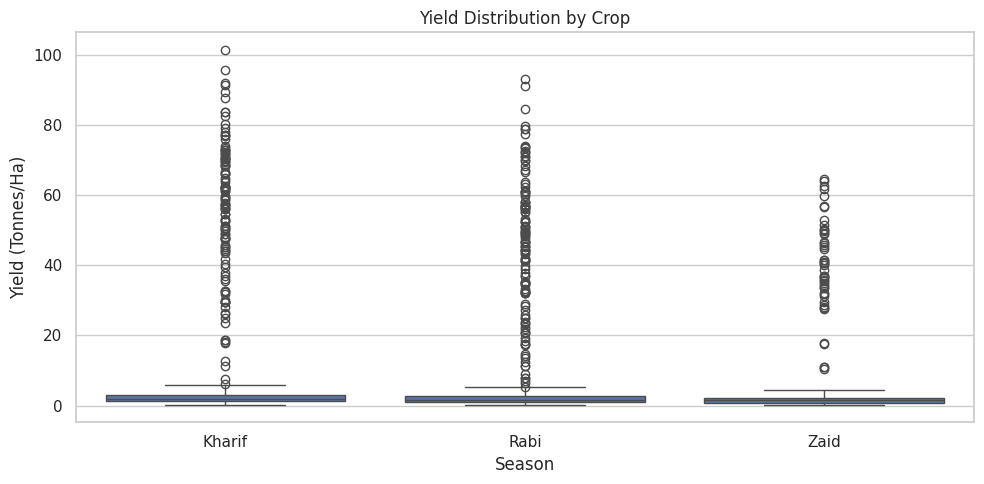

In [51]:
# Bivariate Analysis

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution by Crop")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

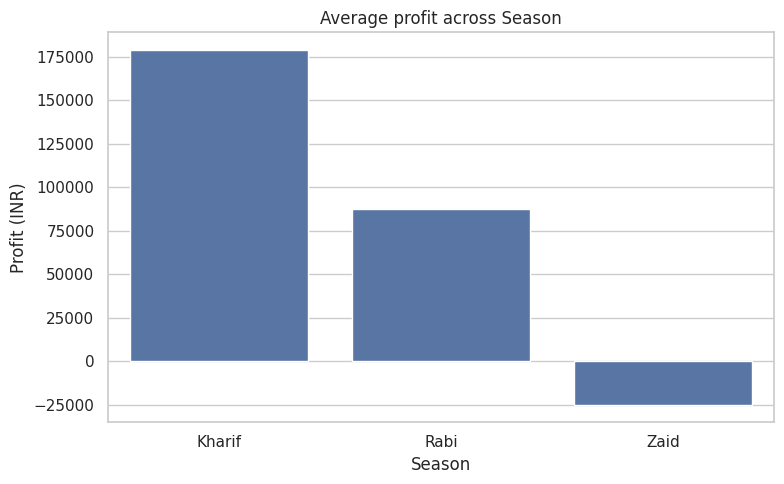

In [53]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar = None)
plt.title("Average profit across Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

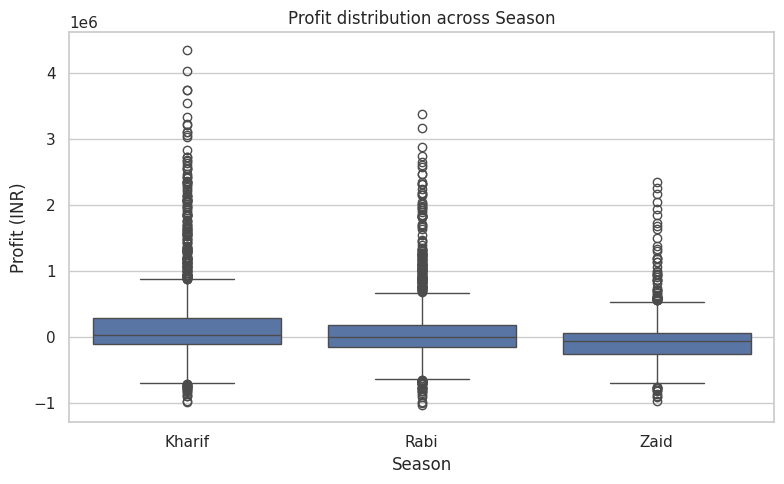

In [54]:
# Bivariate: season vs profit

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR" )
plt.title("Profit distribution across Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

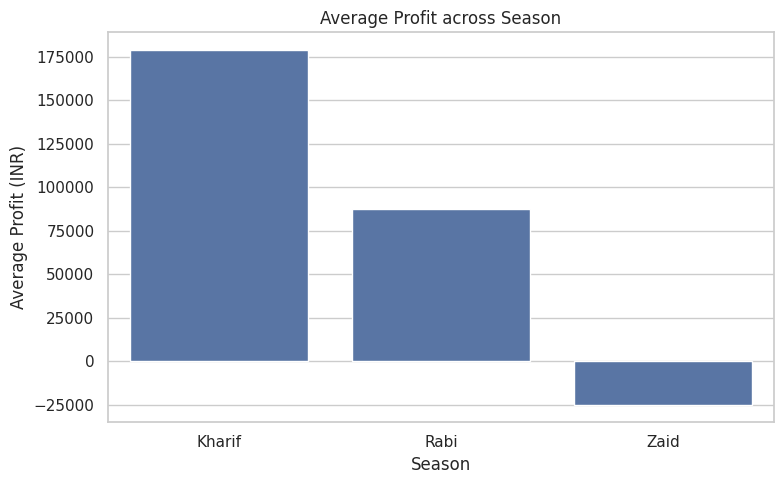

In [55]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar = None)
plt.title("Average Profit across Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

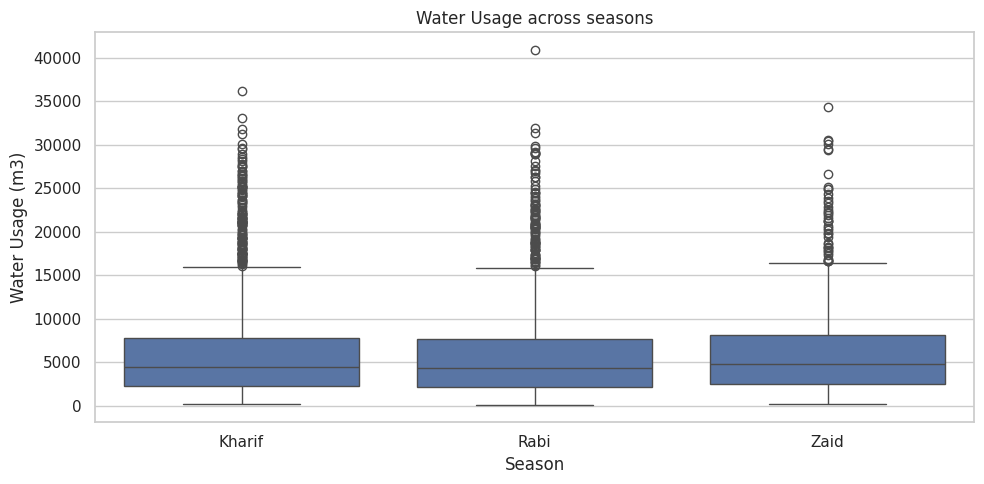

In [56]:
# Bivariate Season vs Water Usage
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage across seasons")
plt.xlabel("Season")
plt.ylabel("Water Usage (m3)")
plt.tight_layout()
plt.show()

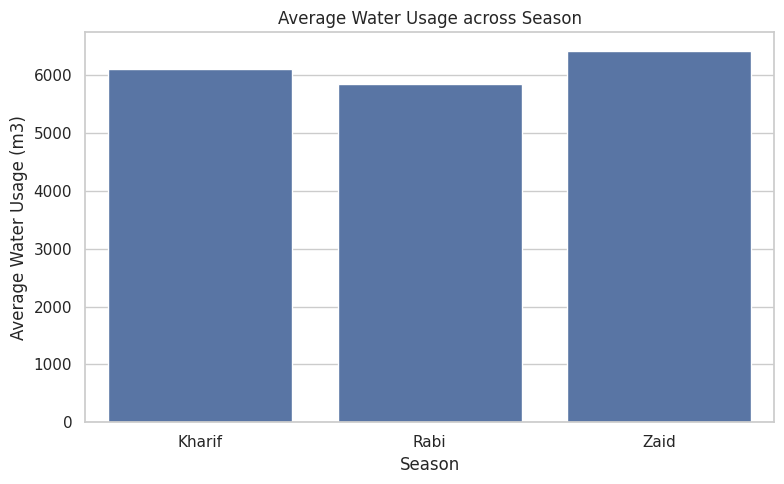

In [57]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar = None)
plt.title("Average Water Usage across Season")
plt.xlabel("Season")
plt.ylabel("Average Water Usage (m3)")
plt.tight_layout()
plt.show()

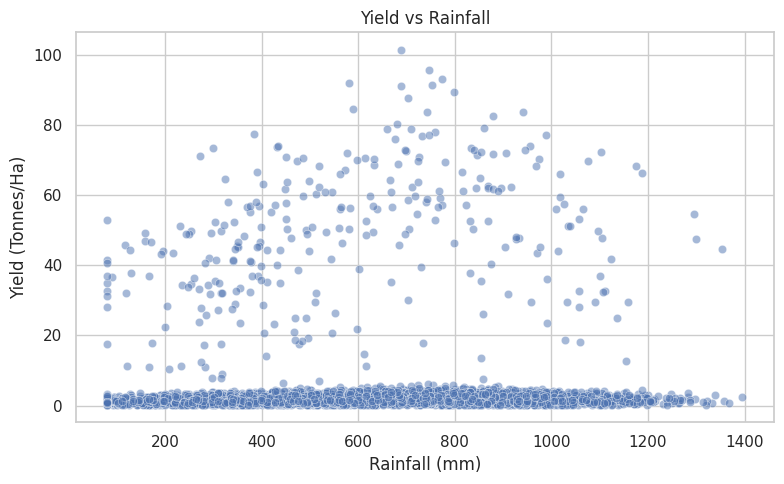

In [58]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha = 0.5 )
plt.title("Yield vs Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

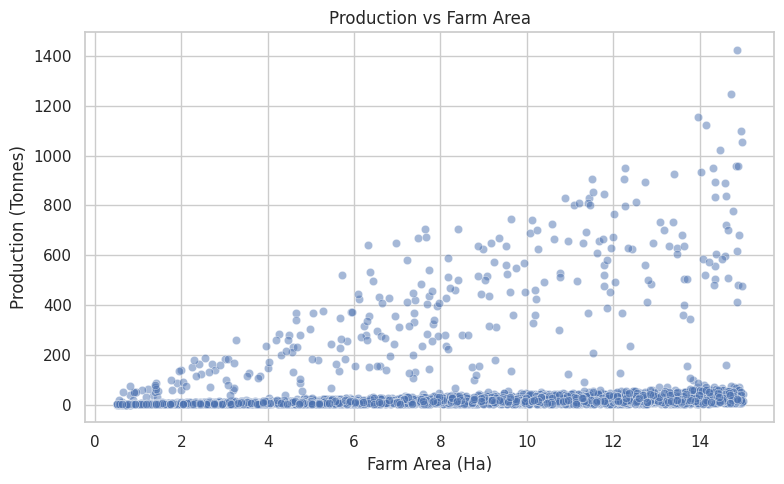

In [60]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha = 0.5)
plt.title("Production vs Farm Area")
plt.xlabel("Farm Area (Ha)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

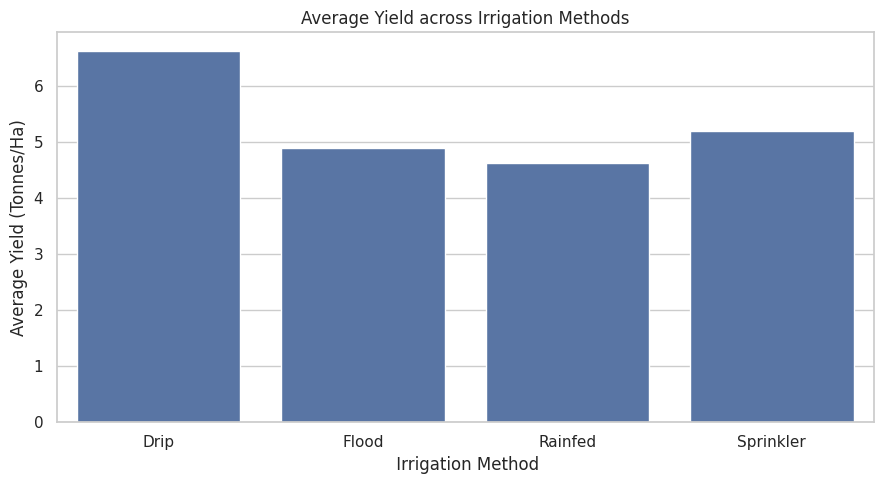

In [62]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar = None)
plt.title("Average Yield across Irrigation Methods")
plt.xlabel(" Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

Multivariate Analysis

It examines more than two variables together.

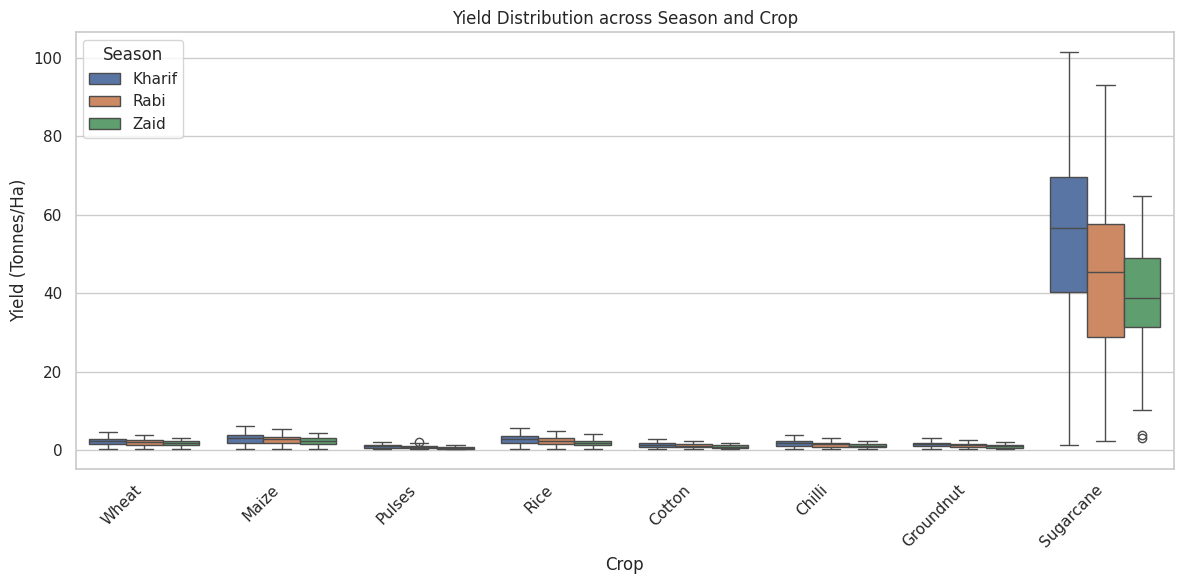

In [65]:
# Multivariate: Season, crop and yield
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season" )
plt.title("Yield Distribution across Season and Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

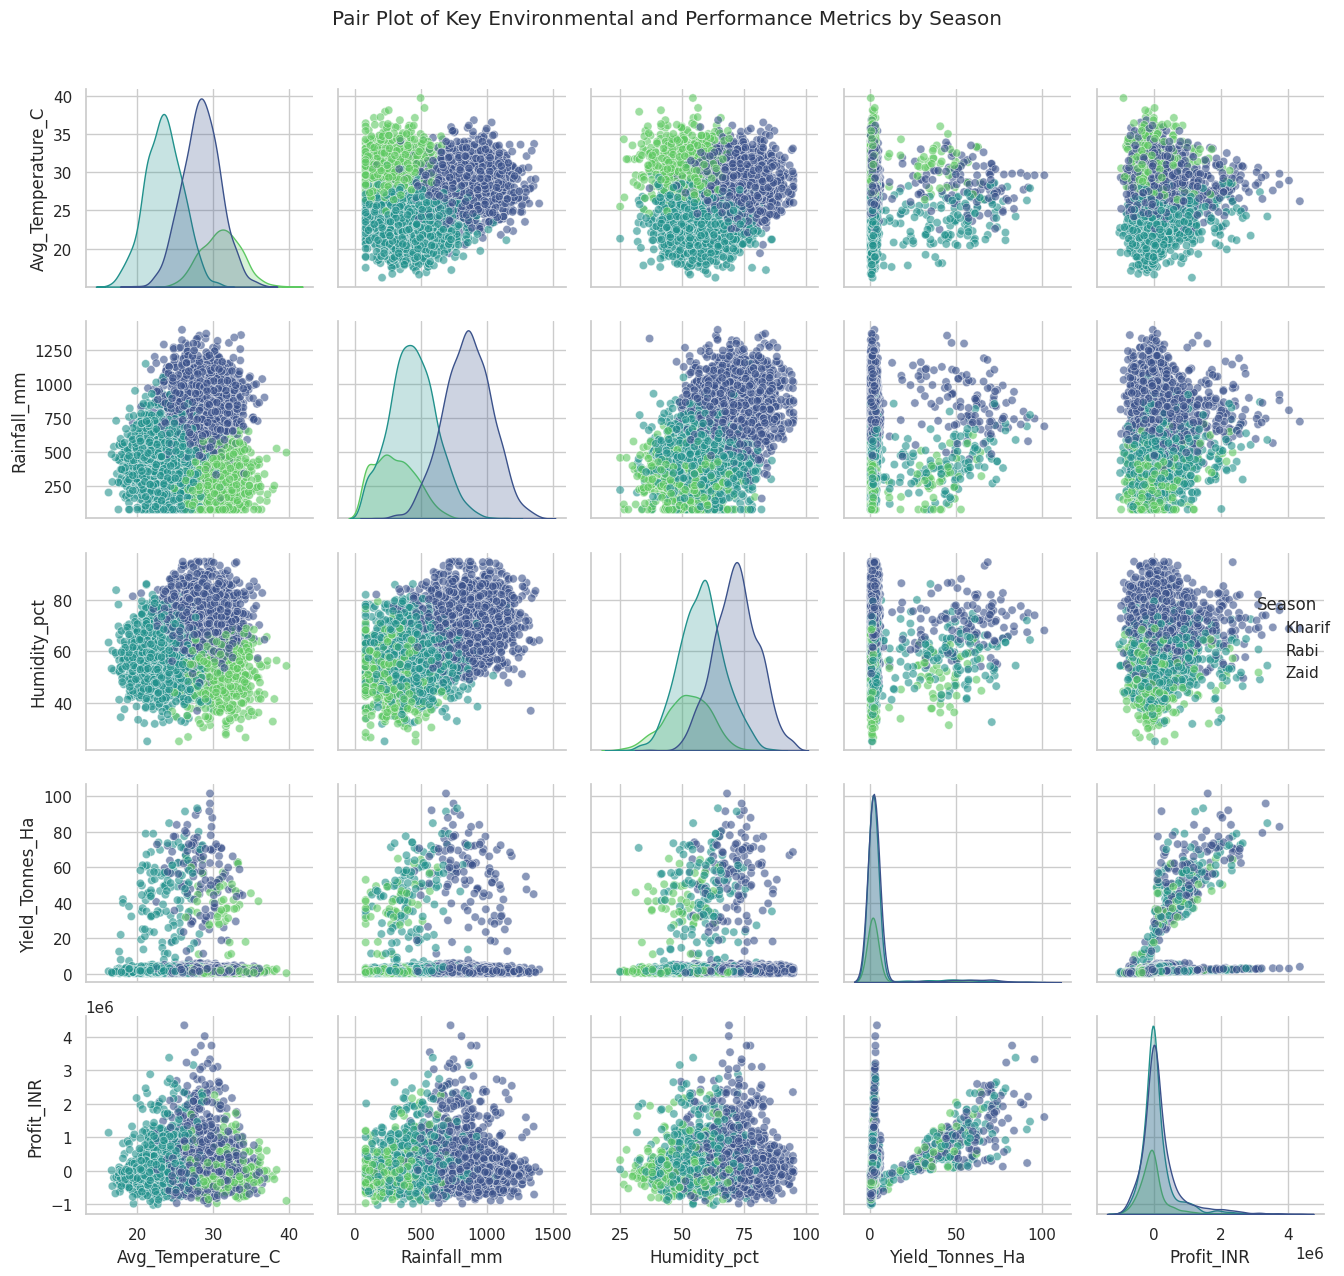

In [66]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Key Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

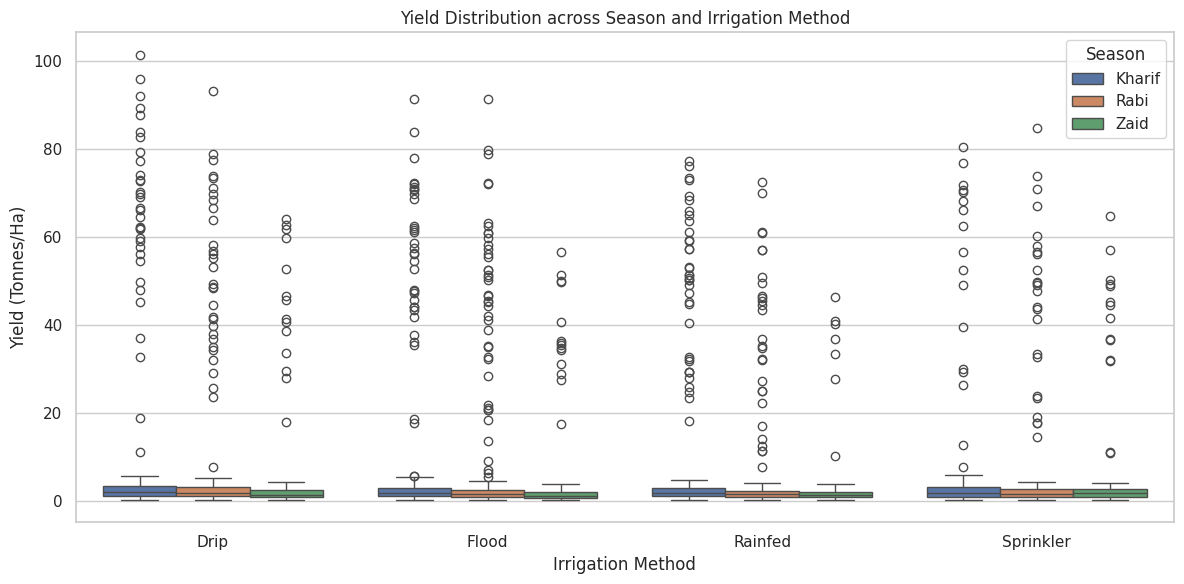

In [67]:
# Multivariate Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season" )
plt.title("Yield Distribution across Season and Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

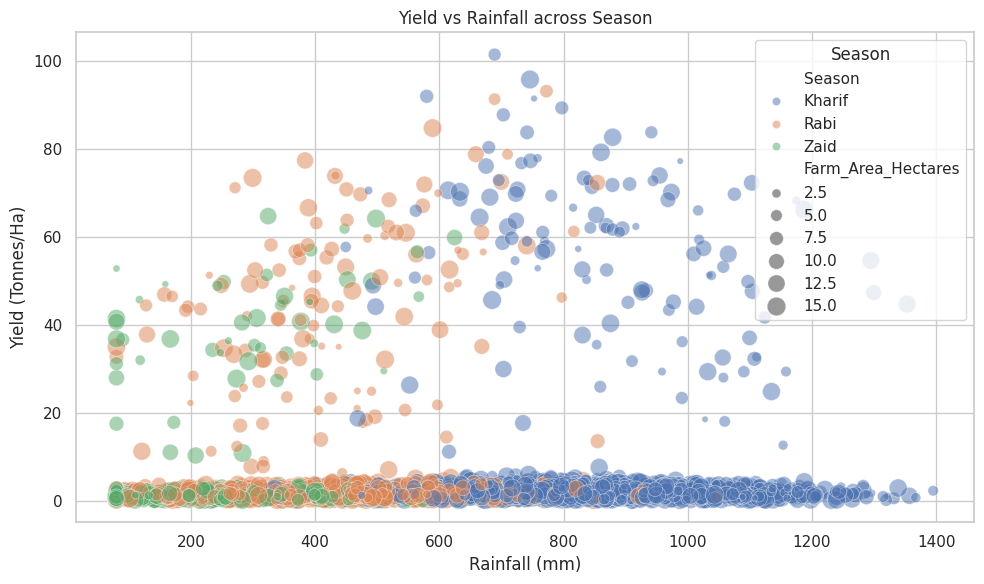

In [68]:
# Multivariate: Rainfall, Yield and Season
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", size = "Farm_Area_Hectares", sizes = (20,180), alpha = 0.5)
plt.title("Yield vs Rainfall across Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

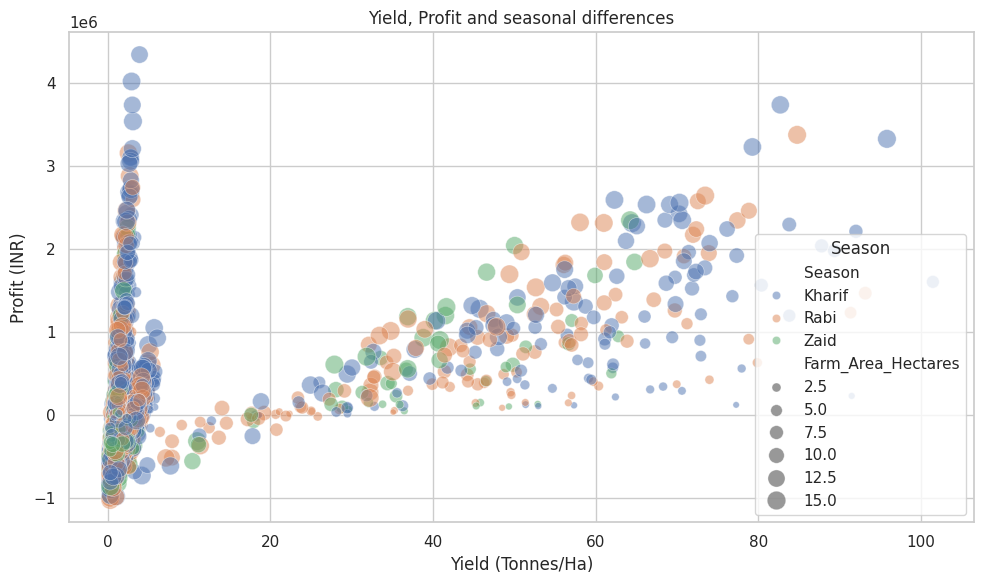

In [69]:
# Multivariate: Profit, Yield and Season

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Yield_Tonnes_Ha", y="Profit_INR", hue="Season", size = "Farm_Area_Hectares", sizes = (20,180), alpha = 0.5)
plt.title("Yield, Profit and seasonal differences")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

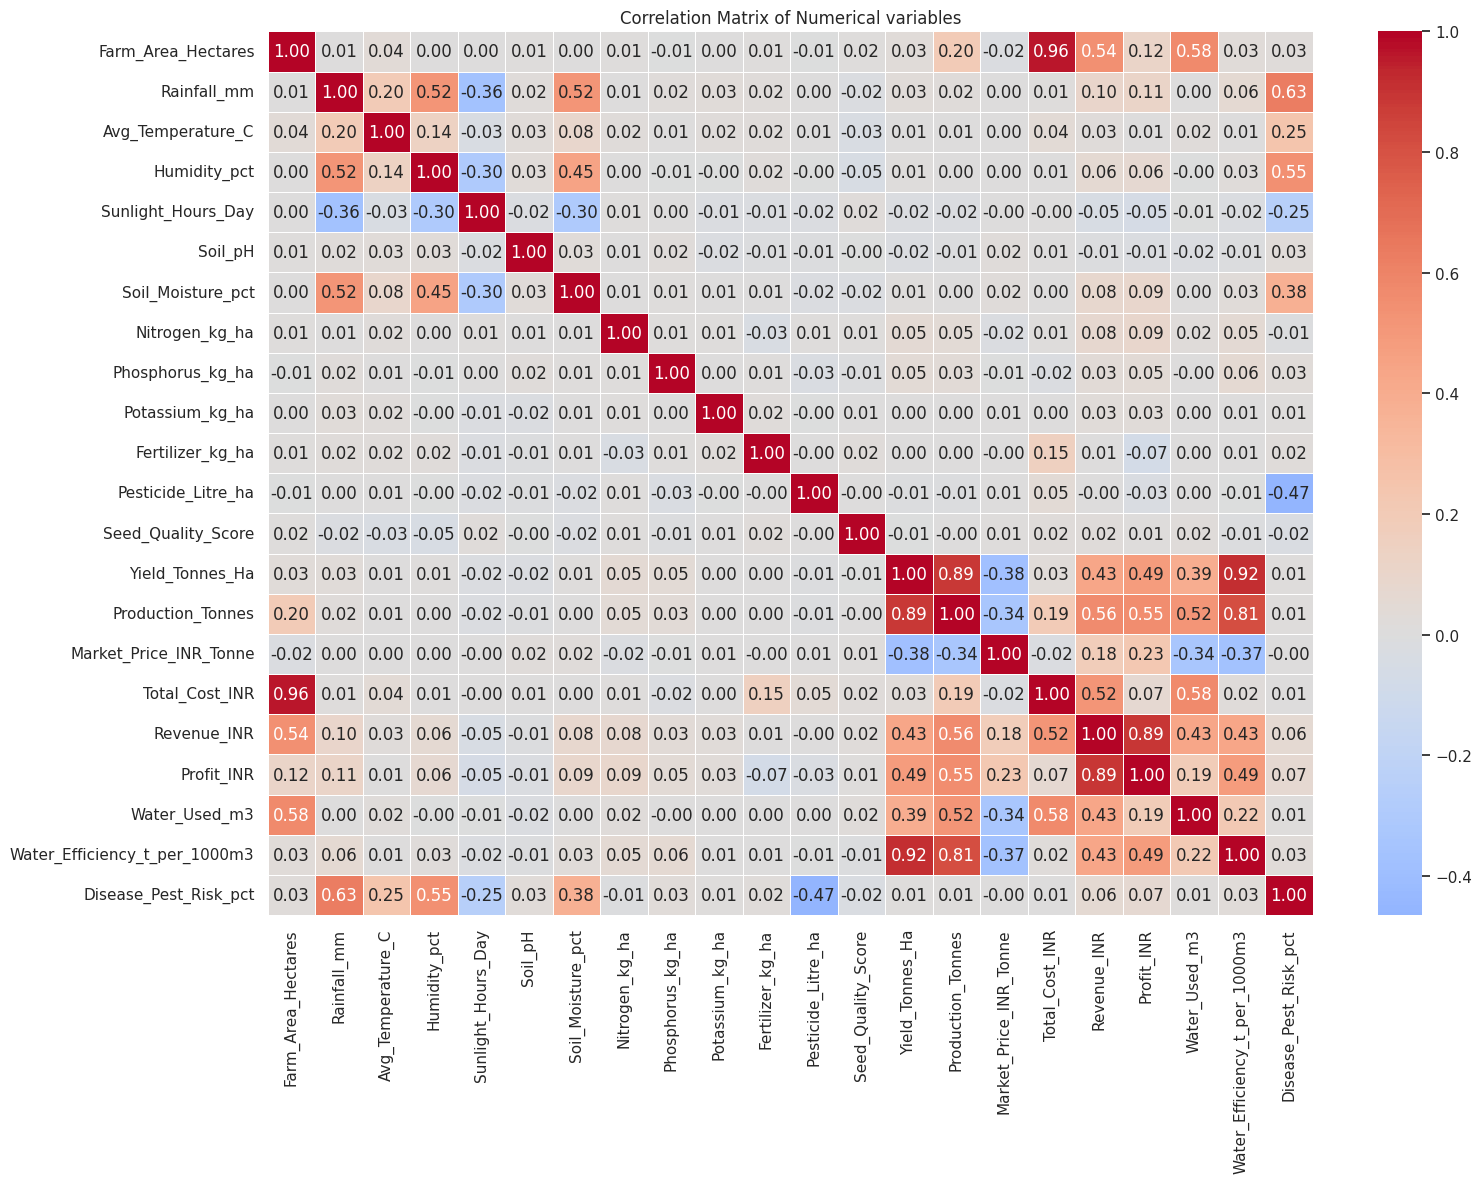

In [71]:
# Correlation heatmap for Numerical Variables

plt.figure(figsize=(16, 12))
corr = df[numerical_column].corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap = 'coolwarm', center = 0, linewidth=0.5)
plt.title("Correlation Matrix of Numerical variables")
plt.tight_layout()
plt.show()

Seasonal Comparison

In [73]:
# General Seasonal Summary
seasonal_metrics= df.groupby("Season").agg(
    Records = ("Farm_ID", "count"),
    Average_Yield = ("Yield_Tonnes_Ha", "mean"),
    Total_Production = ("Production_Tonnes", "sum"),
    Average_Profit = ("Profit_INR", "mean"),
    Average_Rainfall = ("Rainfall_mm", "mean"),
    Average_Humidity = ("Humidity_pct", "mean"),
    Average_Temperature = ("Avg_Temperature_C", "mean"),
    Average_Water_Usage = ("Water_Used_m3", "mean")
).round(2)

seasonal_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Average_Rainfall,Average_Humidity,Average_Temperature,Average_Water_Usage
Season,,,,,,,,
Kharif,1779,5.64,"82,387.61","178,914.65",852.08,71.81,28.45,"6,102.20"
Rabi,1627,5.08,"67,498.88","87,689.47",436.00,57.89,23.49,"5,846.99"
Zaid,594,4.67,"23,098.35","-24,804.82",299.42,52.01,31.04,"6,419.89"


In [75]:
# Compare crop performance within each season

crop_season_summary = ( df.groupby(["Season", "Crop"]).agg(
    Records = ("Farm_ID", "count"),
    Average_Yield = ("Yield_Tonnes_Ha", "mean"),
    Total_Production = ("Production_Tonnes", "sum"),
    Average_Profit = ("Profit_INR", "mean"),
    Average_Water_Efficiency = ("Water_Efficiency_t_per_1000m3", "mean")
).round(2)
 .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)
crop_season_summary

Records  Average_Yield  Total_Production  Average_Profit  \
Season Crop                                                                  
Kharif Sugarcane      125          53.46         55,759.37    1,000,790.81   
       Maize          234           2.97          5,463.54      -39,332.67   
       Rice           314           2.71          7,049.19      -64,903.40   
       Wheat          292           2.26          5,345.95     -105,871.87   
       Chilli         185           1.73          2,675.74      954,380.42   
       Groundnut      193           1.48          2,024.62      108,265.44   
       Cotton         215           1.37          2,237.84      216,999.55   
       Pulses         221           1.04          1,831.36       43,338.90   
Rabi   Sugarcane      129          43.94         47,118.96      731,612.86   
       Maize          233           2.61          5,030.78      -89,133.40   
       Rice           274           2.33          4,719.24      -98,427.87   
       Wheat          237           2.06          3,807.63     -119,954.57   
       Chilli         163           1.46          1,787.45      638,572.50   
       Groundnut      177           1.22          1,603.90       10,416.54   
       Cotton         201           1.19          1,897.64      107,343.59   
       Pulses         213           0.87          1,533.28      -14,309.14   
Zaid   Sugarcane       51          38.42         16,807.64      583,635.80   
       Maize           84           2.30          1,507.08     -194,049.17   
       Rice           102           1.90          1,540.72     -227,239.34   
       Wheat           85           1.75          1,194.72     -193,208.95   
       Chilli          64           1.18            638.56      448,659.09   
       Groundnut       54           1.04            465.55      -68,872.50   
       Cotton          92           0.95            637.62      -53,925.34   
       Pulses          62           0.65            306.46     -139,227.81   

                  Average_Water_Efficiency  
Season Crop                                 
Kharif Sugarcane                     36.00  
       Maize                          6.05  
       Rice                           2.17  
       Wheat                          4.76  
       Chilli                         3.26  
       Groundnut                      3.58  
       Cotton                         2.13  
       Pulses                         3.35  
Rabi   Sugarcane                     27.92  
       Maize                          5.46  
       Rice                           1.84  
       Wheat                          4.69  
       Chilli                         2.89  
       Groundnut                      2.90  
       Cotton                         1.94  
       Pulses                         2.70  
Zaid   Sugarcane                     23.39  
       Maize                          4.75  
       Rice                           1.53  
       Wheat                          4.02  
       Chilli                         2.20  
       Groundnut                      2.47  
       Cotton                         1.49  
       Pulses                         1.95